# Lab 03 — pandas: จาก DataFrame สู่ matrix สำหรับโมเดล
### pandas DataFrame → feature matrix: one-hot, split, normalize, convention bridge

**กลุ่ม:** A พื้นฐาน · **อ่านคู่กับสไลด์หน้า:** 71-73, 98-99, 122 · **เวลาโดยประมาณ:** 75 นาที · **Dataset:** churn_toy.csv (สไลด์ p.72), churn_synthetic.csv (~1,000 แถว) ผ่าน `nnlab.data`

**ควรทำมาก่อน:** Lab 01 (shape, axis, broadcasting)

## จุดประสงค์การเรียนรู้
เมื่อทำ lab นี้จบ นิสิตจะสามารถ
1. โหลด CSV เป็น `DataFrame` แล้วสำรวจด้วย `head` / `info` / `describe` / `value_counts` และเลือกคอลัมน์ กรองแถว `groupby` ได้
2. ตรวจและจัดการ missing value ด้วย `isna().sum()`, `fillna`, `dropna` และรู้ว่าแต่ละวิธีแลกอะไร
3. แปลงคอลัมน์ข้อความเป็นตัวเลขด้วย one-hot encoding (สไลด์ p.72-73) และ map label Yes/No → 1/0 แล้วได้ `X` shape `(m, n_x)`
4. แบ่ง train/test แบบ stratified 80:20 ด้วย numpy เอง (สไลด์ p.122) และ normalize ด้วย μ, σ ของ train เท่านั้น (สไลด์ p.98-99)
5. แปลงข้อมูลจาก library convention `(m, n_x)` ไปเป็น convention สไลด์ `(n_x, m)` และกลับ โดยไม่หลงว่า sample อยู่แถวหรือคอลัมน์

> **วิธีใช้ notebook นี้:** อ่าน markdown cell ก่อน แล้วรัน code cell ถัดไปด้วย `Shift+Enter` ทีละ cell ตามลำดับ
> ทุก code cell มีคำอธิบายว่าทำอะไรและทำไม ถ้าอยากทดลอง ให้แก้ตัวเลขใน cell แล้วรันซ้ำได้เลย

## เตรียมเครื่องมือ
cell แรกของทุก lab จะ import library ที่ใช้ และตั้ง **seed** ให้ตัวเลขสุ่มเหมือนกันทุกครั้งที่รัน
(ไม่งั้นค่าเริ่มต้นของ weight จะต่างกันทุกรอบ และตัวเลขในหน้าจอจะไม่ตรงกับคำอธิบาย)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import nnlab                      # package ประกอบ lab (ติดตั้งแล้วด้วย uv sync)
except ImportError:                   # เผื่อเปิดด้วย kernel อื่น: เพิ่ม lab/src เข้า path เอง
    import sys, pathlib
    sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
    import nnlab

from nnlab.utils import set_seed
import pandas as pd
rng = set_seed(463)                   # 463 = เลขวิชา CP463
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline
print("numpy", np.__version__, "| nnlab", nnlab.__version__)

numpy 2.2.6 | nnlab 0.1.0


## สัญลักษณ์ในบทนี้
| สัญลักษณ์ | ความหมาย | ใน pandas / numpy |
|---|---|---|
| `DataFrame` | ตารางที่คอลัมน์มีชื่อและมี dtype ของตัวเอง | `df` |
| `Series` | คอลัมน์เดียวของ DataFrame (1 มิติ) | `df["churn"]` |
| $m$ | จำนวน sample (แถวของตาราง) | `len(df)`, `X.shape[0]` |
| $n_x$ | จำนวน feature หลัง one-hot | `X.shape[1]` |
| $\mu, \sigma$ | ค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานของแต่ละ feature **จาก train เท่านั้น** (p.98-99) | `X_train.mean(axis=0)`, `X_train.std(axis=0)` |
| $X_{trn}, X_{tst}$ | ข้อมูลส่วน train / test (p.122) | `X_train`, `X_test` |

> **Convention ที่ใช้ในส่วนนี้: library (pandas / scikit-learn / PyTorch)** — `X` มี shape `(m, n_x)` sample เป็น**แถว**, `y` มี shape `(m,)` และ `Z = X @ W.T + b`

สังเกต banner ด้านบน: pandas, scikit-learn และ PyTorch ทุกตัววาง **sample เป็นแถว** `(m, n_x)` แต่สไลด์ของวิชานี้ (และ lab05-07) วาง **sample เป็นคอลัมน์** `(n_x, m)`
ตลอด lab นี้เราอยู่ฝั่ง library ก่อน แล้วค่อยข้าม "สะพาน" ไปฝั่งสไลด์ในขั้นสุดท้าย

## ขั้นที่ 1 · โหลดและสำรวจข้อมูล
โมเดลทุกตัวในคอร์สรับ **matrix ตัวเลข** แต่ข้อมูลจริงมาเป็นตาราง CSV ที่มีทั้งตัวเลข ข้อความ และช่องว่าง — `pandas` คือเครื่องมือแปลงจากตารางไปเป็น matrix
เริ่มจากตารางเล็กในสไลด์ p.72: ลูกค้า 5 คน มี monthly usage (ชั่วโมง), subscription type และ **churn** (เลิกใช้บริการหรือไม่ = สิ่งที่อยากทำนาย)

`load_churn_toy()` อ่านไฟล์ `data/churn_toy.csv` ด้วย `pd.read_csv` ให้เรา — คาดว่าได้ 5 แถว 3 คอลัมน์ และ dtype ของ 2 คอลัมน์เป็น `object` (ข้อความ)

In [2]:
from nnlab.data import load_churn_toy, load_churn_synthetic

df_toy = load_churn_toy()                              # DataFrame 5 แถว × 3 คอลัมน์ (ตารางสไลด์ p.72)
display(df_toy)
print("shape:", df_toy.shape, "| columns:", list(df_toy.columns))
print("\ndtypes:"); print(df_toy.dtypes)
print("\nประเภทของ df_toy['churn']:", type(df_toy["churn"]).__name__, "| shape", df_toy["churn"].shape)

,monthly_usage_hours,subscription_type,churn
0,12,Basic,Yes
1,50,Standard,No
2,8,Premium,Yes
3,30,Standard,No
4,5,Basic,Yes


shape: (5, 3) | columns: ['monthly_usage_hours', 'subscription_type', 'churn']

dtypes:
monthly_usage_hours     int64
subscription_type      object
churn                  object
dtype: object

ประเภทของ df_toy['churn']: Series | shape (5,)


ตาราง 5 แถวเล็กเกินจะเทรนอะไรได้ เราจึงใช้ `churn_synthetic.csv` (~1,000 ลูกค้า สร้างด้วย seed คงที่) เป็นข้อมูลหลัก
คำสั่งสำรวจที่ควรรันทุกครั้งที่เจอข้อมูลใหม่: `head()` ดู 5 แถวแรก, `info()` ดู dtype และจำนวนค่าที่ไม่ว่างของแต่ละคอลัมน์
คาดว่าจะเห็น 1,000 แถว 6 คอลัมน์ มี `customer_id` (ไม่ใช่ feature!), ตัวเลข 3 คอลัมน์, `subscription_type` เป็นข้อความ และ `churn` เป็น 0/1 อยู่แล้ว

In [3]:
df = load_churn_synthetic(as_frame=True)               # as_frame=True → DataFrame ดิบ ยังไม่ one-hot
print("shape:", df.shape, "→ m =", df.shape[0], "แถว")
display(df.head())
df.info()

shape: (1000, 6) → m = 1000 แถว


,customer_id,monthly_usage_hours,tenure_months,support_tickets,subscription_type,churn
0,1,18.2,55,1,Premium,0
1,2,23.3,31,1,Basic,0
2,3,31.6,25,0,Basic,0
3,4,1.9,54,1,Premium,0
4,5,19.3,28,2,Standard,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          1000 non-null   int64  
 1   monthly_usage_hours  1000 non-null   float64
 2   tenure_months        1000 non-null   int64  
 3   support_tickets      1000 non-null   int64  
 4   subscription_type    1000 non-null   object 
 5   churn                1000 non-null   int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 47.0+ KB


`describe()` สรุปสถิติของคอลัมน์ตัวเลข (mean, std, min, quartile, max) — ใช้ดู **scale** ของแต่ละ feature ซึ่งต่างกันมาก (จะเป็นเหตุผลของการ normalize ในขั้นที่ 6)
`value_counts()` นับความถี่ของค่าในคอลัมน์ข้อความ/label; ใส่ `normalize=True` ได้สัดส่วน — **churn rate** ของชุดนี้ประมาณ 31% แปลว่า class ไม่สมดุล (imbalanced)
ตัวเลขนี้ต้องจำไว้ เพราะการแบ่ง train/test ในขั้นที่ 5 ต้องรักษาสัดส่วนนี้

In [4]:
display(df.describe().round(2))
print("subscription_type:"); print(df["subscription_type"].value_counts())
print("\nchurn (สัดส่วน):"); print(df["churn"].value_counts(normalize=True).round(3))
churn_rate = df["churn"].mean()                        # mean ของ 0/1 = สัดส่วนของ 1
print(f"\nchurn rate ทั้งชุด = {churn_rate:.3f} ({df['churn'].sum()} จาก {len(df)} คน)")

,customer_id,monthly_usage_hours,tenure_months,support_tickets,churn
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,500.50,22.80,30.89,1.58,0.31
std,288.82,16.09,17.20,1.26,0.46
min,1.00,0.60,1.00,0.00,0.00
25%,250.75,11.00,17.00,1.00,0.00
50%,500.50,19.15,31.00,1.00,0.00
75%,750.25,30.40,46.00,2.00,1.00
max,1000.00,118.40,60.00,7.00,1.00


subscription_type:
subscription_type
Basic       525
Standard    346
Premium     129
Name: count, dtype: int64

churn (สัดส่วน):
churn
0    0.689
1    0.311
Name: proportion, dtype: float64

churn rate ทั้งชุด = 0.311 (311 จาก 1000 คน)


## ขั้นที่ 2 · เลือกคอลัมน์ · กรองแถว · groupby
สามคำสั่งที่ใช้บ่อยที่สุด
- **เลือกคอลัมน์**: `df["col"]` ได้ `Series` (1 มิติ) · `df[["c1", "c2"]]` (list ซ้อน) ได้ `DataFrame`
- **กรองแถว**: สร้าง boolean mask เช่น `df["monthly_usage_hours"] > 40` แล้วใส่ใน `df[mask]` — เหมือน boolean indexing ของ numpy
- **`loc` / `iloc`**: `loc` อ้างด้วยชื่อ (label) · `iloc` อ้างด้วยตำแหน่งตัวเลขเหมือน numpy

คาดว่า Series มี shape `(1000,)` และลูกค้าที่ใช้เกิน 40 ชั่วโมงมีไม่กี่สิบคน

In [5]:
usage = df["monthly_usage_hours"]                      # Series: (1000,)
print(type(usage).__name__, usage.shape, "| mean =", round(usage.mean(), 2))

two_cols = df[["monthly_usage_hours", "tenure_months"]]   # DataFrame: (1000, 2)
print(type(two_cols).__name__, two_cols.shape)

heavy = df[df["monthly_usage_hours"] > 40]             # กรองแถวด้วย boolean mask
print(f"\nลูกค้าที่ใช้ > 40 ชม.: {len(heavy)} คน, churn rate ในกลุ่มนี้ = {heavy['churn'].mean():.3f}")

print("\ndf.loc[0:2, ['customer_id', 'churn']]  (label: รวมแถว 2 ด้วย)")
display(df.loc[0:2, ["customer_id", "churn"]])
print("df.iloc[:3, :3]  (ตำแหน่ง: ไม่รวมแถว 3 เหมือน numpy)")
display(df.iloc[:3, :3])

Series (1000,) | mean = 22.8
DataFrame (1000, 2)

ลูกค้าที่ใช้ > 40 ชม.: 145 คน, churn rate ในกลุ่มนี้ = 0.090

df.loc[0:2, ['customer_id', 'churn']]  (label: รวมแถว 2 ด้วย)


,customer_id,churn
0,1,0
1,2,0
2,3,0


df.iloc[:3, :3]  (ตำแหน่ง: ไม่รวมแถว 3 เหมือน numpy)


,customer_id,monthly_usage_hours,tenure_months
0,1,18.2,55
1,2,23.3,31
2,3,31.6,25


`groupby` แบ่งตารางตามค่าในคอลัมน์หนึ่ง แล้วสรุปแต่ละกลุ่ม — คำถามที่ควรถามก่อนสร้างโมเดล: "subscription type บอกอะไรเกี่ยวกับ churn ไหม?"
ถ้า churn rate ของแต่ละ type ต่างกันชัด แสดงว่าคอลัมน์นี้เป็น feature ที่มีประโยชน์ และคุ้มที่จะแปลงเป็นตัวเลข (ขั้นที่ 4)
คาดว่า Basic churn สูงสุด และ Premium ต่ำสุด

churn rate ต่อ subscription_type:
subscription_type
Basic       0.366
Premium     0.178
Standard    0.277
Name: churn, dtype: float64


,count,churn_rate
subscription_type,,
Basic,525,0.366
Premium,129,0.178
Standard,346,0.277


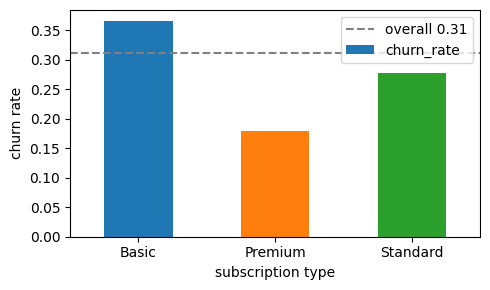

In [6]:
print("churn rate ต่อ subscription_type:")
print(df.groupby("subscription_type")["churn"].mean().round(3))          # Series: 1 ค่าต่อ type

by_type = df.groupby("subscription_type")["churn"].agg(["count", "mean"]).rename(columns={"mean": "churn_rate"})
display(by_type.round(3))

fig, ax = plt.subplots(figsize=(5, 3))
by_type["churn_rate"].plot.bar(ax=ax, color=["C0", "C1", "C2"], legend=False)
ax.axhline(churn_rate, color="gray", ls="--", label=f"overall {churn_rate:.2f}")
ax.set_ylabel("churn rate"); ax.set_xlabel("subscription type"); ax.legend(); ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

## ขั้นที่ 3 · missing values
ข้อมูลจริงมักมีช่องว่าง (`NaN`) — ถ้าปล่อยเข้าโมเดล ทุกอย่างที่คูณกับ `NaN` จะกลายเป็น `NaN` ทั้ง network
ชุดข้อมูลของเราสะอาดอยู่แล้ว (ดู `info()` ด้านบน: Non-Null 1000 ทุกคอลัมน์) เราจึง**จำลอง**ปัญหา: copy ตารางแล้วสุ่มลบค่าด้วย `rng` — 5 ช่องใน usage และ 3 ช่องใน tenure

สังเกต pitfall หนึ่งข้อ: `tenure_months` เดิมเป็น `int64` แต่พอมี `NaN` แม้แค่ 1 ช่อง pandas จะเปลี่ยนทั้งคอลัมน์เป็น `float64` เพราะจำนวนเต็มไม่มีตัวแทนของ "ว่าง"

In [7]:
df_na = df.copy()
idx_usage = rng.choice(len(df_na), size=5, replace=False)     # สุ่มแถว 5 แถว ไม่ซ้ำ
idx_tenure = rng.choice(len(df_na), size=3, replace=False)
df_na.loc[idx_usage, "monthly_usage_hours"] = np.nan
df_na.loc[idx_tenure, "tenure_months"] = np.nan

print("จำนวน NaN ต่อคอลัมน์:"); print(df_na.isna().sum())
print("\ndtype ของ tenure_months: เดิม", df["tenure_months"].dtype, "→ หลังมี NaN", df_na["tenure_months"].dtype)
print("\nแถวที่มี NaN (บางส่วน):")
display(df_na[df_na.isna().any(axis=1)].head())

จำนวน NaN ต่อคอลัมน์:
customer_id            0
monthly_usage_hours    5
tenure_months          3
support_tickets        0
subscription_type      0
churn                  0
dtype: int64

dtype ของ tenure_months: เดิม int64 → หลังมี NaN float64

แถวที่มี NaN (บางส่วน):


,customer_id,monthly_usage_hours,tenure_months,support_tickets,subscription_type,churn
269,270,37.3,NaN,0,Standard,0
290,291,NaN,29.0,1,Premium,0
353,354,NaN,57.0,1,Premium,0
569,570,NaN,8.0,2,Basic,0
706,707,NaN,57.0,1,Basic,0


สองทางเลือกหลัก
1. **`dropna()`** ทิ้งแถวที่มีช่องว่าง — ง่าย แต่เสียข้อมูล (ที่นี่เสีย ≤ 8 แถว แต่ในข้อมูลจริงอาจเสียครึ่งตาราง)
2. **`fillna(ค่าแทน)`** เติมค่า — นิยมใช้ **median** ของคอลัมน์ เพราะทนต่อค่าผิดปกติกว่า mean (usage มี max 118 ขณะ median ≈ 19)

กติกาเดียวกับ normalize: ถ้ามีการแบ่ง train/test ค่าที่ใช้เติมต้องคำนวณจาก train เท่านั้น (ที่นี่ยังไม่แบ่ง จึงใช้ทั้งตารางเพื่อสาธิต)
คาดว่าหลังเติมแล้ว `isna().sum()` เป็น 0 ทุกคอลัมน์ และค่าที่เติมคือ median

In [8]:
print("dropna : shape", df_na.shape, "→", df_na.dropna().shape, "(เสีย", len(df_na) - len(df_na.dropna()), "แถว)")

medians = df_na[["monthly_usage_hours", "tenure_months"]].median()   # Series ของ median แต่ละคอลัมน์
print("\nmedian ที่จะใช้เติม:"); print(medians)
df_filled = df_na.fillna(medians)                     # เติมเฉพาะคอลัมน์ที่อยู่ใน medians
print("\nหลัง fillna → NaN เหลือ:", int(df_filled.isna().sum().sum()), "| shape", df_filled.shape)
print("ค่าที่ถูกเติมในแถว", idx_usage[:3], ":", df_filled.loc[idx_usage[:3], "monthly_usage_hours"].tolist())

dropna : shape (1000, 6) → (992, 6) (เสีย 8 แถว)

median ที่จะใช้เติม:
monthly_usage_hours    19.1
tenure_months          31.0
dtype: float64

หลัง fillna → NaN เหลือ: 0 | shape (1000, 6)
ค่าที่ถูกเติมในแถว [569 706 353] : [19.1, 19.1, 19.1]


## ขั้นที่ 4 · one-hot encoding และ label → 0/1 (สไลด์ p.72-73)
`subscription_type` เป็นข้อความ โมเดลคูณกับข้อความไม่ได้ ทางเลือกแรกที่คนมักนึกถึงคือแทนด้วย Basic=0, Standard=1, Premium=2
แต่นั่นบอกโมเดลโดยไม่ตั้งใจว่า Premium "มากกว่า" Standard และ Premium−Basic = 2 เท่าของ Standard−Basic ซึ่งไม่มีความหมาย

**one-hot encoding** แก้โดยสร้างคอลัมน์ใหม่ 1 คอลัมน์ต่อ 1 ค่า แล้วใส่ 1 ในคอลัมน์ที่ตรง ใส่ 0 ที่เหลือ (สไลด์ p.73)
pandas ทำให้ด้วย `pd.get_dummies` — ค่าเริ่มต้นให้ `True/False` เราใส่ `dtype=int` ให้เป็น 0/1 และเรียงคอลัมน์ให้ตรงกับสไลด์ (Basic, Standard, Premium) เพราะ pandas เรียงตามตัวอักษร
คาดว่าได้ตาราง 5 × 3 ที่ทุกแถวมี 1 ตัวเดียว ตรงกับ p.73 ทุกช่อง

In [9]:
onehot_toy = pd.get_dummies(df_toy["subscription_type"], dtype=int)     # (5, 3) คอลัมน์เรียงตามตัวอักษร
print("คอลัมน์ที่ pandas สร้าง:", list(onehot_toy.columns))
onehot_toy = onehot_toy[["Basic", "Standard", "Premium"]]              # เรียงตามสไลด์ p.73
onehot_toy.insert(0, "subscription_type", df_toy["subscription_type"])   # แปะคอลัมน์เดิมไว้ซ้ายเพื่อเทียบสายตา
display(onehot_toy)
row_sums = onehot_toy[["Basic", "Standard", "Premium"]].sum(axis=1).to_numpy()   # (5,)
assert (row_sums == 1).all()
print("ทุกแถวมี 1 ตัวเดียว:", row_sums, "✓")

คอลัมน์ที่ pandas สร้าง: ['Basic', 'Premium', 'Standard']


,subscription_type,Basic,Standard,Premium
0,Basic,1,0,0
1,Standard,0,1,0
2,Premium,0,0,1
3,Standard,0,1,0
4,Basic,1,0,0


ทุกแถวมี 1 ตัวเดียว: [1 1 1 1 1] ✓


ทำทั้งตาราง: `pd.get_dummies(df, columns=[...])` จะแทนคอลัมน์ที่ระบุด้วยคอลัมน์ one-hot (ชื่อ `subscription_type_Basic` เป็นต้น) และคงคอลัมน์อื่นไว้
ส่วน label `churn` เป็น Yes/No ต้อง map เป็น 1/0 ด้วย `.map({...})` — ให้ **1 = class ที่เราสนใจ** (ลูกค้าเลิกใช้) ตามธรรมเนียม positive class
คาดว่าตารางสุดท้ายเป็นตัวเลขทั้งหมด (dtype `int64`) 5 แถว 5 คอลัมน์

In [10]:
df_toy_num = pd.get_dummies(df_toy, columns=["subscription_type"], dtype=int)
df_toy_num["churn"] = df_toy["churn"].map({"Yes": 1, "No": 0})    # Yes → 1 (positive class), No → 0
display(df_toy_num)
print(df_toy_num.dtypes)
assert df_toy_num["churn"].tolist() == [1, 0, 1, 0, 1]             # ตรงกับคอลัมน์ Y ของสไลด์ p.72

,monthly_usage_hours,churn,subscription_type_Basic,subscription_type_Premium,subscription_type_Standard
0,12,1,1,0,0
1,50,0,0,0,1
2,8,1,0,1,0
3,30,0,0,0,1
4,5,1,1,0,0


monthly_usage_hours           int64
churn                         int64
subscription_type_Basic       int64
subscription_type_Premium     int64
subscription_type_Standard    int64
dtype: object


ทีนี้ทำกับ `churn_synthetic` จริง สามขั้น
1. ตัด `customer_id` ออก — เลขประจำตัวไม่มีข้อมูลเกี่ยวกับ churn ถ้าปล่อยไว้โมเดลจะ "จำ" ลูกค้าแทนที่จะเรียนรู้ (และตัด `churn` ออกจาก feature เพราะมันคือคำตอบ)
2. one-hot `subscription_type`
3. `to_numpy(dtype=float)` เพื่อออกจาก pandas ไปเป็น `ndarray` — ตั้งแต่บรรทัดนี้เราอยู่ในโลก numpy ของ lab01

คาดว่า `X` มี shape `(1000, 6)` = 3 feature ตัวเลข + 3 คอลัมน์ one-hot และ `y` มี shape `(1000,)` — library convention ตาม banner ด้านบน

In [11]:
features = pd.get_dummies(df.drop(columns=["customer_id", "churn"]), columns=["subscription_type"], dtype=int)
feature_names = list(features.columns)
X = features.to_numpy(dtype=float)                    # X: (m, n_x) = (1000, 6)  sample เป็นแถว
y = df["churn"].to_numpy(dtype=int)                    # y: (m,) = (1000,)
m, n_x = X.shape
print("feature_names:", feature_names)
print("X:", X.shape, X.dtype, "| y:", y.shape, y.dtype, "| m =", m, "n_x =", n_x)
print("\nX[:3] =\n", X[:3])
print("y[:10] =", y[:10])
assert not np.isnan(X).any(), "ยังมี NaN หลุดเข้ามา!"

feature_names: ['monthly_usage_hours', 'tenure_months', 'support_tickets', 'subscription_type_Basic', 'subscription_type_Premium', 'subscription_type_Standard']
X: (1000, 6) float64 | y: (1000,) int64 | m = 1000 n_x = 6

X[:3] =
 [[18.2 55.   1.   0.   1.   0. ]
 [23.3 31.   1.   1.   0.   0. ]
 [31.6 25.   0.   1.   0.   0. ]]
y[:10] = [0 0 0 0 0 0 1 0 1 0]


## ขั้นที่ 5 · แบ่ง train/test แบบ stratified (สไลด์ p.122)
เราต้องเก็บข้อมูลส่วนหนึ่งไว้เป็น **test set** ที่โมเดลไม่เคยเห็น เพื่อวัดว่ามันทำนายลูกค้าใหม่ได้จริงไหม สไลด์แนะ 80:20 หรือ 70:30 สำหรับข้อมูลไม่ใหญ่
และต้องแบ่งแบบ **stratified**: รักษาสัดส่วน yes/no ให้เท่าเดิมทั้งสองฝั่ง — ถ้าสุ่มมั่ว test อาจได้ churn 25% ขณะ train 33% แล้วตัวเลขประเมินจะเพี้ยน

กลไกเขียนเองได้ใน 6 บรรทัด: วนทีละ class → สลับ index ของ class นั้นด้วย `rng` → ตัด 20% แรกเป็น test ที่เหลือเป็น train → รวมทุก class แล้วสลับอีกรอบ
คาดว่า train 800 / test 200 และ churn rate ทั้งสองฝั่ง ≈ 0.311 เท่าชุดเต็ม

In [12]:
def stratified_split_by_hand(X, y, test_ratio, rng):
    """แบ่ง train/test โดยสุ่มภายในแต่ละ class แยกกัน แล้วตัดตามสัดส่วนเดียวกัน"""
    train_idx, test_idx = [], []
    for c in np.unique(y):                             # วนทีละ class (0 แล้ว 1)
        idx = np.flatnonzero(y == c)                   # index ของ sample ที่เป็น class c
        rng.shuffle(idx)                               # สลับในที่
        n_test = int(round(len(idx) * test_ratio))
        test_idx.extend(idx[:n_test]); train_idx.extend(idx[n_test:])
    train_idx = rng.permutation(np.array(train_idx))   # สลับอีกรอบ ไม่ให้ class เรียงติดกัน
    test_idx = rng.permutation(np.array(test_idx))
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train, X_test, y_train, y_test = stratified_split_by_hand(X, y, 0.2, rng)
print("X_train:", X_train.shape, "| X_test:", X_test.shape, "| y_train:", y_train.shape, "| y_test:", y_test.shape)
print(f"churn rate  all = {y.mean():.3f} | train = {y_train.mean():.3f} | test = {y_test.mean():.3f}")
print(f"จำนวน churn=1   all = {y.sum()} | train = {y_train.sum()} | test = {y_test.sum()}")

X_train: (800, 6) | X_test: (200, 6) | y_train: (800,) | y_test: (200,)
churn rate  all = 0.311 | train = 0.311 | test = 0.310
จำนวน churn=1   all = 311 | train = 249 | test = 62


scikit-learn มี `train_test_split` ให้ — ใส่ `stratify=y` จะได้พฤติกรรมเดียวกับที่เราเขียน (สัดส่วนตรง แม้แถวที่ถูกเลือกจะต่างกันเพราะสุ่มคนละชุด)
ลองเทียบสามแบบ: ของเรา, sklearn แบบ stratified และ sklearn แบบ**ไม่** stratified — แบบสุดท้ายสัดส่วน test จะคลาดจาก 0.311 เล็กน้อย (ที่นี่ข้อมูล 1,000 แถวจึงคลาดไม่มาก แต่กับข้อมูล 100 แถวจะเห็นชัด)

In [13]:
from sklearn.model_selection import train_test_split

Xtr_sk, Xte_sk, ytr_sk, yte_sk = train_test_split(X, y, test_size=0.2, stratify=y, random_state=463)
Xtr_ns, Xte_ns, ytr_ns, yte_ns = train_test_split(X, y, test_size=0.2, stratify=None, random_state=463)

print(f"{'วิธี':28s}{'train rate':>12s}{'test rate':>12s}{'n_test':>8s}")
print(f"{'เขียนเอง (stratified)':28s}{y_train.mean():12.3f}{y_test.mean():12.3f}{len(y_test):8d}")
print(f"{'sklearn stratify=y':28s}{ytr_sk.mean():12.3f}{yte_sk.mean():12.3f}{len(yte_sk):8d}")
print(f"{'sklearn stratify=None':28s}{ytr_ns.mean():12.3f}{yte_ns.mean():12.3f}{len(yte_ns):8d}")
assert abs(y_test.mean() - yte_sk.mean()) < 0.01     # stratified สองวิธีให้สัดส่วนเท่ากัน

# ข้อมูลเล็ก 100 แถว: ไม่ stratify แล้วสัดส่วนเพี้ยนชัด
_, _, _, yte_small = train_test_split(X[:100], y[:100], test_size=0.2, stratify=None, random_state=463)
print(f"\n100 แถวแรก: churn rate ทั้งชุด = {y[:100].mean():.2f} แต่ test (ไม่ stratify) = {yte_small.mean():.2f}")

วิธี                          train rate   test rate  n_test
เขียนเอง (stratified)              0.311       0.310     200
sklearn stratify=y                 0.311       0.310     200
sklearn stratify=None              0.305       0.335     200

100 แถวแรก: churn rate ทั้งชุด = 0.33 แต่ test (ไม่ stratify) = 0.25


## ขั้นที่ 6 · normalize ด้วย μ และ σ ของ train เท่านั้น (สไลด์ p.98-99)
ดู scale ของ feature: usage อยู่ราว 0-118, tenure 0-70, tickets 0-10, one-hot 0/1 — ต่างกันเป็นสิบเท่า
gradient descent จะวิ่งช้าและซิกแซ็กเมื่อ feature มี scale ต่างกัน (สไลด์ p.98 "x1 has higher variance compared to x2") วิธีแก้คือทำให้ทุก feature มี mean 0 และ variance 1
$$\mu = \frac{1}{m}\sum_{i=1}^{m} x^{(i)}, \qquad \sigma^2 = \frac{1}{m}\sum_{i=1}^{m} (x^{(i)} - \mu)^2, \qquad X := \frac{X - \mu}{\sigma}$$

กติกาสำคัญที่สุดของหน้า p.99: **"μ and σ² from training set will be used in test set"** — คำนวณ μ, σ จาก `X_train` แล้วนำค่าเดียวกันไปใช้กับ `X_test`
`axis=0` เพราะเฉลี่ยข้าม sample (แถว) ให้ได้ค่าหนึ่งต่อ feature; `keepdims=True` ให้ได้ `(1, n_x)` แล้ว broadcast ลบทุกแถวได้ทันที (lab01 ขั้นที่ 5)

In [14]:
print("scale ก่อน normalize (train):")
print(f"{'feature':28s}{'min':>8s}{'max':>8s}{'mean':>8s}{'std':>8s}")
for j, name in enumerate(feature_names):
    col = X_train[:, j]
    print(f"{name:28s}{col.min():8.2f}{col.max():8.2f}{col.mean():8.2f}{col.std():8.2f}")

mu = X_train.mean(axis=0, keepdims=True)              # mu:    (1, n_x)  จาก train เท่านั้น
sigma = X_train.std(axis=0, keepdims=True)            # sigma: (1, n_x)  ddof=0 ตรงกับ 1/m ในสไลด์
X_train_n = (X_train - mu) / sigma                     # (800, 6) - (1, 6) → broadcast ทุกแถว
X_test_n = (X_test - mu) / sigma                       # ใช้ mu, sigma ของ train!

print("\nหลัง normalize:")
print("train mean =", X_train_n.mean(axis=0), "\ntrain std  =", X_train_n.std(axis=0))
print("test  mean =", X_test_n.mean(axis=0), "\ntest  std  =", X_test_n.std(axis=0))
assert np.allclose(X_train_n.mean(axis=0), 0) and np.allclose(X_train_n.std(axis=0), 1)

scale ก่อน normalize (train):
feature                          min     max    mean     std
monthly_usage_hours             0.60  118.40   23.06   16.29
tenure_months                   1.00   60.00   30.85   17.41
support_tickets                 0.00    7.00    1.60    1.28
subscription_type_Basic         0.00    1.00    0.52    0.50
subscription_type_Premium       0.00    1.00    0.12    0.32
subscription_type_Standard      0.00    1.00    0.36    0.48

หลัง normalize:
train mean = [ 0. -0.  0.  0.  0. -0.] 
train std  = [1. 1. 1. 1. 1. 1.]
test  mean = [-0.0787  0.0119 -0.0772  0.0875  0.1385 -0.1845] 
test  std  = [0.9305 0.9351 0.9387 0.9933 1.1422 0.9282]


สังเกตว่า train ได้ mean 0.0000 และ std 1.0000 เป๊ะ แต่ **test ไม่ได้ 0 และ 1 พอดี** (เช่น mean ≈ ±0.1) — นี่**ถูกต้องและควรเป็นแบบนี้**
เพราะ test คือข้อมูล "อนาคต" ที่เราไม่รู้ค่าเฉลี่ยของมันจริง ๆ; ถ้าคำนวณ μ, σ จาก test เอง หรือจากทั้งชุดก่อนแบ่ง ข้อมูล test จะ "รั่ว" (leak) เข้าไปในขั้นเทรน
ทำให้ตัวเลขประเมินดีเกินจริง แล้วพอใช้กับลูกค้าใหม่จริง ๆ ผลจะแย่กว่าที่คิด

cell นี้แสดงตัวเลขของสองวิธีเทียบกัน: ค่า μ ของ test เองต่างจาก μ ของ train เล็กน้อยทุกคอลัมน์ — ความต่างนี้แหละที่ห้ามให้โมเดล "แอบรู้"

In [15]:
mu_test_own = X_test.mean(axis=0)                     # (n_x,) — สิ่งที่ห้ามใช้ตอนเทรน
print(f"{'feature':28s}{'mu train':>10s}{'mu test':>10s}{'diff':>8s}")
for j, name in enumerate(feature_names):
    print(f"{name:28s}{mu[0, j]:10.3f}{mu_test_own[j]:10.3f}{mu_test_own[j] - mu[0, j]:8.3f}")

X_test_leaky = (X_test - mu_test_own) / X_test.std(axis=0)   # ผิด: fit บน test
print("\ntest mean ถ้าใช้สถิติของ test เอง =", X_test_leaky.mean(axis=0).round(4), "← สวยแต่ 'รั่ว'")
print("test mean ที่ถูกต้อง (สถิติ train) =", X_test_n.mean(axis=0).round(4), "← ไม่เป็น 0 พอดี และนั่นถูกแล้ว")

feature                       mu train   mu test    diff
monthly_usage_hours             23.056    21.773  -1.283
tenure_months                   30.848    31.055   0.207
support_tickets                  1.604     1.505  -0.099
subscription_type_Basic          0.516     0.560   0.044
subscription_type_Premium        0.120     0.165   0.045
subscription_type_Standard       0.364     0.275  -0.089

test mean ถ้าใช้สถิติของ test เอง = [ 0.  0.  0. -0. -0. -0.] ← สวยแต่ 'รั่ว'
test mean ที่ถูกต้อง (สถิติ train) = [-0.0787  0.0119 -0.0772  0.0875  0.1385 -0.1845] ← ไม่เป็น 0 พอดี และนั่นถูกแล้ว


> **Convention ที่ใช้ในส่วนนี้: สไลด์ (deck)** — `X` มี shape `(n_x, m)` sample เป็น**คอลัมน์**, `Y` มี shape `(1, m)`, `w` มี shape `(n_x, 1)` และ `Z = w.T @ X + b`

## ขั้นที่ 7 · สะพานสู่ convention ของสไลด์
ถึงตรงนี้ `X_train_n` มี shape `(800, 6)` = library convention แต่สูตรทุกหน้าในสไลด์ (และ lab05-07) เขียนด้วย $X \in \mathbb{R}^{n_x \times m}$ — **sample เป็นคอลัมน์** และ $Y \in \mathbb{R}^{1 \times m}$
การข้ามฝั่งคือ transpose ครั้งเดียว `X_deck = X_rows.T` และ `Y = y.reshape(1, -1)` แต่ต้องทำ**อย่างรู้ตัว**: ถ้าเผลอส่ง `(m, n_x)` เข้าสูตรที่คาด `(n_x, m)` โค้ดจะ error
หรือแย่กว่านั้นคือ**รันผ่านแต่ผลผิด** เมื่อ $m = n_x$ บังเอิญเท่ากัน

cell นี้ข้ามสะพานแล้วตรวจสองอย่าง: (1) sample แรกของฝั่ง lib (แถว 0) ต้องเท่ากับคอลัมน์ 0 ของฝั่ง deck, (2) คำนวณ $Z$ ทั้งสอง convention ด้วย weight ชุดเดียวกันแล้วต้องได้ค่าเดียวกัน (แค่ transpose กัน)

In [16]:
X_deck = X_train_n.T                                   # X_deck: (n_x, m) = (6, 800)  sample เป็นคอลัมน์
Y_deck = y_train.reshape(1, -1)                        # Y_deck: (1, m)   = (1, 800)
X_test_deck, Y_test_deck = X_test_n.T, y_test.reshape(1, -1)   # (6, 200), (1, 200)
print("lib : X_train_n", X_train_n.shape, "| y_train", y_train.shape)
print("deck: X_deck   ", X_deck.shape, "| Y_deck ", Y_deck.shape, "| X_test_deck", X_test_deck.shape)
assert np.allclose(X_deck[:, 0], X_train_n[0, :])     # sample แรก: คอลัมน์ 0 ของ deck = แถว 0 ของ lib
print("sample แรก (deck คอลัมน์ 0) =", X_deck[:, 0].round(3))

# weight ชุดเดียวกัน คำนวณ Z ทั้งสองแบบ
w = rng.standard_normal((n_x, 1)) * 0.1               # w: (n_x, 1)
b = 0.0
Z_deck = w.T @ X_deck + b                              # (1, n_x) @ (n_x, m) → (1, m)   สูตรสไลด์
Z_lib = X_train_n @ w + b                              # (m, n_x) @ (n_x, 1) → (m, 1)   สูตร library
print("Z_deck", Z_deck.shape, "| Z_lib", Z_lib.shape)
assert np.allclose(Z_deck, Z_lib.T)
print("Z_deck == Z_lib.T ทุกตัว ✓  → ข้อมูลเดียวกัน ต่างแค่วางแนวไหน")

lib : X_train_n (800, 6) | y_train (800,)
deck: X_deck    (6, 800) | Y_deck  (1, 800) | X_test_deck (6, 200)
sample แรก (deck คอลัมน์ 0) = [-0.648  1.444 -0.472  0.968 -0.369 -0.756]
Z_deck (1, 800) | Z_lib (800, 1)
Z_deck == Z_lib.T ทุกตัว ✓  → ข้อมูลเดียวกัน ต่างแค่วางแนวไหน


## ขั้นที่ 8 · เวอร์ชัน production ใน `nnlab`
โค้ดที่เราเพิ่งเขียนใน cell ด้านบนคือ "โค้ดเพื่อความเข้าใจ" — แยกทุกขั้นให้เห็น
ในการใช้งานจริง โค้ดเดียวกันถูกจัดเป็นฟังก์ชัน/คลาสใน `src/nnlab/preprocessing.py` พร้อม docstring, type hints และ test
cell ถัดไปเรียกเวอร์ชัน production มาเทียบกับที่เราเขียนเอง (`StandardNormalizer`, `stratified_split` ใน data.py และ `to_deck` ใน conventions.py) — ตัวเลขต้องตรงกัน
เปิดไฟล์ `src/nnlab/preprocessing.py` ควบคู่กันเพื่อดูว่าโค้ด "ทดลอง" กลายเป็นโค้ด "ใช้งานจริง" ได้อย่างไร

In [17]:
from nnlab.preprocessing import StandardNormalizer
from nnlab.data import stratified_split
from nnlab.conventions import to_deck, to_lib, describe

# 1) one-hot + to_numpy ของ nnlab ต้องให้ X, y, ชื่อ feature เหมือนเรา
X_lib, y_lib, names_lib = load_churn_synthetic()      # as_frame=False → one-hot แล้ว
assert np.allclose(X_lib, X) and np.array_equal(y_lib, y) and names_lib == feature_names
print("one-hot ตรงกับ nnlab.data.load_churn_synthetic ✓  X", X_lib.shape)

# 2) stratified_split ใช้ algorithm เดียวกับที่เราเขียน — ป้อน generator seed เดียวกันแล้วได้แถวเดียวกันเป๊ะ
Xtr_lib, Xte_lib, ytr_lib, yte_lib = stratified_split(X, y, test_ratio=0.2, seed=463)
Xtr_me, Xte_me, ytr_me, yte_me = stratified_split_by_hand(X, y, 0.2, np.random.default_rng(463))
assert np.array_equal(Xtr_lib, Xtr_me) and np.array_equal(yte_lib, yte_me)
print(f"stratified_split ตรงกับที่เขียนเอง ✓  train {Xtr_lib.shape} test {Xte_lib.shape} test rate {yte_lib.mean():.3f}")

# 3) StandardNormalizer: fit บน train แล้ว transform ทั้งคู่
norm = StandardNormalizer().fit(X_train)
assert np.allclose(norm.mean_, mu[0]) and np.allclose(norm.std_, sigma[0])
assert np.allclose(norm.transform(X_train), X_train_n) and np.allclose(norm.transform(X_test), X_test_n)
print("StandardNormalizer ตรงกับ (X - mu) / sigma ของเรา ✓")

# 4) to_deck / to_lib: สะพานสองทาง
Xd, Yd = to_deck(X_train_n, y_train)
assert np.array_equal(Xd, X_deck) and np.array_equal(Yd, Y_deck)
Xr, yr = to_lib(Xd, Yd)
assert np.array_equal(Xr, X_train_n) and np.array_equal(yr, y_train)
print("to_deck :", describe(Xd, "deck"))
print("to_lib  :", describe(Xr, "lib"))

one-hot ตรงกับ nnlab.data.load_churn_synthetic ✓  X (1000, 6)
stratified_split ตรงกับที่เขียนเอง ✓  train (800, 6) test (200, 6) test rate 0.310
StandardNormalizer ตรงกับ (X - mu) / sigma ของเรา ✓
to_deck : shape (6, 800) → n_x=6 features, m=800 samples (sample เป็นคอลัมน์)
to_lib  : shape (800, 6) → m=800 samples, n_x=6 features (sample เป็นแถว)


## ★ Key Takeaways
- `pandas` คือขั้นแปลงตาราง CSV → matrix: สำรวจด้วย `head/info/describe/value_counts` ก่อนเสมอ และตัดคอลัมน์ ID กับ label ออกจาก feature
- `groupby` ตอบคำถาม "คอลัมน์นี้บอกอะไรเกี่ยวกับ label" — churn rate Basic > Standard > Premium จึงคุ้มที่จะ one-hot
- missing value: `isna().sum()` ตรวจ, `dropna` เสียแถว, `fillna(median)` เก็บแถว; NaN ทำให้คอลัมน์ int กลายเป็น float
- one-hot (`pd.get_dummies(dtype=int)`) แทนหมวดหมู่ด้วยคอลัมน์ 0/1 ไม่สร้างลำดับปลอม; label Yes/No → 1/0 ด้วย `.map` โดย 1 = class ที่สนใจ
- แบ่ง train/test แบบ stratified (สุ่มภายในแต่ละ class) รักษาสัดส่วน 0.311 ทั้งสองฝั่ง; normalize ด้วย μ, σ ของ **train เท่านั้น** — test ไม่ได้ mean 0 พอดีและนั่นถูกแล้ว
- library วาง sample เป็นแถว `(m, n_x)` สไลด์วางเป็นคอลัมน์ `(n_x, m)`; ข้ามด้วย `.T` และ `reshape(1, -1)` อย่างรู้ตัว — `to_deck` / `to_lib` ช่วยได้

## แบบฝึกหัด (ทำเอง)
ส่วนนี้ต้อง**เขียนโค้ดเอง** — แต่ละข้อมี 3 cell: โจทย์ (อ่านให้จบก่อน) → cell โครง (มี `raise NotImplementedError` ให้แทนที่ด้วยโค้ดของคุณ) → cell ตรวจคำตอบ
cell ตรวจคำตอบรันได้ทันที: ถ้ายังไม่ได้ทำจะขึ้น ⏳ ถ้าผิดจะขึ้น ✗ พร้อมคำใบ้ ถ้าถูกจะขึ้น ✓ PASS
ทำได้ไม่จำกัดรอบ แก้แล้วรัน cell โครงและ cell ตรวจซ้ำ ใช้ผลจาก cell ก่อนหน้าใน lab นี้ได้ทุกตัว

In [18]:
from nnlab.exercise import check, check_close, check_shape, summary, reset
reset()   # ล้างผลการตรวจเก่าใน kernel นี้

### แบบฝึกหัด 3.1 · churn rate ตามช่วงอายุการใช้งาน (pd.cut + groupby)
**เป้าหมาย:** แบ่งลูกค้าตาม `tenure_months` เป็น 4 ช่วงด้วย `pd.cut` แล้วหา churn rate ของแต่ละช่วงด้วย `groupby` — ลูกค้าใหม่หรือลูกค้าเก่าเลิกใช้บริการมากกว่ากัน?

**ขั้นตอน**
1. `tenure_bins = [0, 12, 24, 48, 100]` กำหนดให้แล้ว → 4 ช่วง (0,12], (12,24], (24,48], (48,100] (pd.cut นับขอบขวาเข้าช่วง)
2. กำหนด `tenure_bucket` = ผลของ `pd.cut(...)` บนคอลัมน์ `df["tenure_months"]` ด้วย `bins=tenure_bins` — ได้ Series ยาว 1000 ที่บอกว่าแต่ละแถวอยู่ช่วงไหน
3. กำหนด `rate_by_tenure` = churn rate ต่อช่วง: `groupby` รับ Series ได้โดยตรง (ไม่ต้องเป็นชื่อคอลัมน์) แล้วเลือกคอลัมน์ `churn` และ `.mean()` — แบบเดียวกับ groupby ตาม subscription_type ในขั้นที่ 2
4. อ่านค่าช่วงแรกและช่วงสุดท้ายออกมาเป็นตัวเลขด้วย `.iloc[0]` และ `.iloc[-1]` ใส่ใน `rate_new`, `rate_old`

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- `pd.cut(df["tenure_months"], bins=tenure_bins)`
- `df.groupby(tenure_bucket)["churn"].mean()` — ถ้าเห็น FutureWarning เรื่อง observed ให้ใส่ `observed=True` ใน groupby ได้ (ไม่มีผลกับค่า)
- `rate_by_tenure.iloc[0]` ได้ตัวเลขของช่วงแรก
</details>

In [19]:
# --- แบบฝึกหัด 3.1: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
tenure_bins = [0, 12, 24, 48, 100]
tenure_bucket = ...            # TODO: pd.cut ของ df["tenure_months"] ตาม tenure_bins → Series (1000,)   ← แทน ... ด้วยโค้ดของคุณ
rate_by_tenure = ...           # TODO: churn rate ของแต่ละช่วง → Series 4 ค่า
print(rate_by_tenure)
rate_new = ...                 # TODO: churn rate ของช่วงแรก (0, 12] เป็นตัวเลข
rate_old = ...                 # TODO: churn rate ของช่วงสุดท้าย (48, 100]

Ellipsis


In [20]:
# --- ตรวจคำตอบ 3.1 (รันได้ทันที ไม่ต้องแก้) ---
# อ้างอิงคนละวิธี: boolean mask ทีละช่วง (lo, hi] แบบขั้นที่ 2 — ไม่ใช้ pd.cut / groupby
ref_rates = []
for lo, hi in zip([0, 12, 24, 48], [12, 24, 48, 100]):
    in_range = (df["tenure_months"] > lo) & (df["tenure_months"] <= hi)
    ref_rates.append(df.loc[in_range, "churn"].mean())
check_shape("3.1 tenure_bucket ยาวเท่า df", lambda: tenure_bucket, (len(df),), hint="pd.cut คืน Series ยาวเท่า input เสมอ")
check_shape("3.1 rate_by_tenure มี 4 ค่า", lambda: rate_by_tenure, (4,), hint="groupby(tenure_bucket)['churn'].mean() ให้ 1 ค่าต่อช่วง")
check_close("3.1 churn rate แต่ละช่วงตรงกับวิธี mask", lambda: rate_by_tenure, ref_rates, hint="mean ของคอลัมน์ churn (0/1) = สัดส่วนที่ churn ในช่วงนั้น")
ok_new = check_close("3.1 rate_new = ช่วง (0, 12]", lambda: rate_new, ref_rates[0], hint=".iloc[0] คือช่วงแรก")
ok_old = check_close("3.1 rate_old = ช่วง (48, 100]", lambda: rate_old, ref_rates[-1], hint=".iloc[-1] คือช่วงสุดท้าย")
if ok_new and ok_old:
    print(f"→ ลูกค้า{'ใหม่' if rate_new > rate_old else 'เก่า'} churn มากกว่า ({max(rate_new, rate_old):.3f} vs {min(rate_new, rate_old):.3f}) — tenure เป็น feature ที่มีประโยชน์ต่อโมเดล")

⏳ 3.1 tenure_bucket ยาวเท่า df: ยังไม่ได้ทำ
⏳ 3.1 rate_by_tenure มี 4 ค่า: ยังไม่ได้ทำ
⏳ 3.1 churn rate แต่ละช่วงตรงกับวิธี mask: ยังไม่ได้ทำ
⏳ 3.1 rate_new = ช่วง (0, 12]: ยังไม่ได้ทำ
⏳ 3.1 rate_old = ช่วง (48, 100]: ยังไม่ได้ทำ


### แบบฝึกหัด 3.2 · feature ใหม่: จัดกลุ่ม support_tickets แล้ว one-hot
**เป้าหมาย:** เขียน `ticket_level_onehot(tickets)` ที่รับ Series จำนวน ticket แล้วคืน DataFrame one-hot 3 คอลัมน์ `none` (0 ครั้ง) / `few` (1-2 ครั้ง) / `many` (3 ครั้งขึ้นไป) เป็น 0/1 — ต่อเข้ากับ `X` แล้วจะได้ feature 9 ตัว

**ขั้นตอน**
1. ในตัวฟังก์ชัน: จัดกลุ่มด้วย `pd.cut(tickets, bins=[-1, 0, 2, np.inf], labels=['none', 'few', 'many'])` — ช่วง (-1,0] คือ 0 ครั้ง, (0,2] คือ 1-2 ครั้ง, (2,∞) คือ 3 ขึ้นไป
2. one-hot ผลที่ได้ด้วย `pd.get_dummies(..., dtype=int)` (ขั้นที่ 4) แล้ว `return` DataFrame ที่คอลัมน์เรียง none, few, many (pd.cut ที่ใส่ labels จะเรียงตาม labels ให้อยู่แล้ว)
3. ทดสอบกับ `df['support_tickets']` → คาดว่า shape (1000, 3) ทุกแถวมี 1 ตัวเดียว และ `np.hstack([X, ....to_numpy()])` ได้ (1000, 9)

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- `level = pd.cut(tickets, bins=[-1, 0, 2, np.inf], labels=['none', 'few', 'many'])` แล้ว `return pd.get_dummies(level, dtype=int)`
- ถ้าอยากใช้ `np.select` แทน pd.cut ก็ได้ แต่ต้องเรียงคอลัมน์เองหลัง get_dummies
</details>

In [21]:
# --- แบบฝึกหัด 3.2: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def ticket_level_onehot(tickets):
    """tickets: Series (m,) จำนวนเต็ม → DataFrame (m, 3) คอลัมน์ ["none", "few", "many"] ค่า 0/1"""
    raise NotImplementedError("ยังไม่ได้ทำ")

# onehot_tickets = ticket_level_onehot(df["support_tickets"]); display(onehot_tickets.head()); print(onehot_tickets.sum())

In [22]:
# --- ตรวจคำตอบ 3.2 (รันได้ทันที ไม่ต้องแก้) ---
# อ้างอิงคนละวิธี: นับด้วยการเปรียบเทียบตรงๆ ไม่ใช้ pd.cut
t = df["support_tickets"]
ref_counts = [int((t == 0).sum()), int(((t >= 1) & (t <= 2)).sum()), int((t >= 3).sum())]
check_shape("3.2 shape (1000, 3)", lambda: ticket_level_onehot(t), (len(df), 3), hint="pd.get_dummies ของ Series ที่มี 3 กลุ่ม → 3 คอลัมน์")
check("3.2 ชื่อคอลัมน์เรียง none, few, many", lambda: list(ticket_level_onehot(t).columns) == ["none", "few", "many"], hint="ถ้าใช้วิธีอื่นที่ได้ข้อความธรรมดา pandas จะเรียงตามตัวอักษร — เรียงเองด้วย [['none', 'few', 'many']]")
check("3.2 ทุกแถวมี 1 ตัวเดียว", lambda: (ticket_level_onehot(t).sum(axis=1) == 1).all(), hint="แต่ละแถวต้องอยู่กลุ่มเดียว — ตรวจว่า bins ครอบคลุมทุกค่าตั้งแต่ 0 ถึงค่าสูงสุด")
check_close("3.2 จำนวนต่อกลุ่มตรงกับการนับตรงๆ", lambda: ticket_level_onehot(t).sum(axis=0).to_numpy(), ref_counts, hint="ขอบช่วง: 0 → none, 1-2 → few, 3 ขึ้นไป → many (pd.cut นับขอบขวาเข้าช่วง จึงเริ่ม bins ที่ -1)")
small = pd.Series([0, 1, 2, 3, 7])
check_close("3.2 ตัวอย่างเล็ก [0, 1, 2, 3, 7]", lambda: ticket_level_onehot(small).to_numpy(), [[1, 0, 0], [0, 1, 0], [0, 1, 0], [0, 0, 1], [0, 0, 1]], hint="แถวละ 1 ตัวในคอลัมน์ none/few/many ตามลำดับ")
check_shape("3.2 ต่อกับ X แล้วได้ (1000, 9)", lambda: np.hstack([X, ticket_level_onehot(t).to_numpy()]), (len(df), 9))

⏳ 3.2 shape (1000, 3): ยังไม่ได้ทำ
⏳ 3.2 ชื่อคอลัมน์เรียง none, few, many: ยังไม่ได้ทำ
⏳ 3.2 ทุกแถวมี 1 ตัวเดียว: ยังไม่ได้ทำ
⏳ 3.2 จำนวนต่อกลุ่มตรงกับการนับตรงๆ: ยังไม่ได้ทำ
⏳ 3.2 ตัวอย่างเล็ก [0, 1, 2, 3, 7]: ยังไม่ได้ทำ
⏳ 3.2 ต่อกับ X แล้วได้ (1000, 9): ยังไม่ได้ทำ


False

### แบบฝึกหัด 3.3 · แบ่ง 70:30 แบบ stratified ด้วย index แล้ว normalize ด้วยสถิติของ train
**เป้าหมาย:** เขียนกลไก split ใหม่ให้คืน **index** ของ train/test (แทนที่จะคืน array อย่าง `stratified_split_by_hand`) และฟังก์ชัน normalize ที่ใช้ μ, σ ของ train เท่านั้น — ตรวจว่าขนาด 700/300, ไม่มีแถวซ้ำกัน, churn rate ใกล้ 0.311 และ test ไม่ 'รั่ว'

**ขั้นตอน**
1. เขียน `stratified_split_indices(y, test_ratio, rng)` ตามกลไกในขั้นที่ 5: วนทีละ class ด้วย `np.unique(y)` → `np.flatnonzero(y == c)` → `rng.shuffle` → ตัด `int(round(len(idx) * test_ratio))` ตัวแรกเป็น test ที่เหลือเป็น train → รวมทุก class แล้ว `rng.permutation` ทั้งสองฝั่ง — คืน `(train_idx, test_idx)` เป็น numpy array ของ index (ไม่ต้อง index X)
2. เขียน `normalize_with_train(X, train_idx, test_idx)`: คำนวณ `mu`, `sigma` จาก `X[train_idx]` เท่านั้น (`axis=0`) แล้วคืน `(X_train_n, X_test_n)` ที่ลบ mu หาร sigma ทั้งสองฝั่งด้วยค่าชุดเดียวกัน (ขั้นที่ 6)
3. ทดลอง: `tr, te = stratified_split_indices(y, 0.3, rng)` แล้วดูว่า `len(te) == 300`, `y[te].mean()` ใกล้ `y.mean()` และ `normalize_with_train(X, tr, te)[1].mean(axis=0)` ไม่ใช่ 0 พอดี (ถูกแล้ว — ดูขั้นที่ 6)

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- split: ดู `stratified_split_by_hand` ในขั้นที่ 5 เป็นแนวทาง — ต่างกันแค่บรรทัดสุดท้ายคืน `train_idx, test_idx` แทน `X[train_idx], ...`
- normalize: `mu = X[train_idx].mean(axis=0); sigma = X[train_idx].std(axis=0)` แล้วคืน `(X[train_idx] - mu) / sigma, (X[test_idx] - mu) / sigma`
- `np.intersect1d(a, b)` คืนค่าที่อยู่ในทั้งสอง array — ถ้าว่างแปลว่าไม่ซ้ำกัน
</details>

In [23]:
# --- แบบฝึกหัด 3.3: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def stratified_split_indices(y, test_ratio, rng):
    """y: (m,) label 0/1 → (train_idx, test_idx) index ของแต่ละฝั่ง รวมกันครบ m ตัว ไม่ซ้ำกัน"""
    raise NotImplementedError("ยังไม่ได้ทำ")

def normalize_with_train(X, train_idx, test_idx):
    """คืน (X_train_n, X_test_n) ที่ normalize ด้วย mu, sigma ของ X[train_idx] เท่านั้น"""
    raise NotImplementedError("ยังไม่ได้ทำ")

# tr, te = stratified_split_indices(y, 0.3, rng); print(len(tr), len(te), y[te].mean())
# Xtr_n, Xte_n = normalize_with_train(X, tr, te); print(Xtr_n.mean(axis=0), Xte_n.mean(axis=0))

In [24]:
# --- ตรวจคำตอบ 3.3 (รันได้ทันที ไม่ต้องแก้) ---
from nnlab.preprocessing import StandardNormalizer
split = lambda: stratified_split_indices(y, 0.3, np.random.default_rng(7))     # seed คงที่ → เรียกซ้ำได้ผลเดิม
check("3.3 ขนาด train 700 / test 300", lambda: len(split()[0]) == 700 and len(split()[1]) == 300, hint="n_test ของแต่ละ class = int(round(len(idx) * test_ratio)) → 207 + 93 = 300")
check("3.3 ไม่มี index ซ้ำระหว่าง train กับ test", lambda: len(np.intersect1d(split()[0], split()[1])) == 0, hint="test เอา idx[:n_test] แล้ว train ต้องเอา idx[n_test:] จาก idx ชุดเดียวกัน")
check("3.3 รวมกันครบทุกแถว 0..999", lambda: np.array_equal(np.sort(np.concatenate(split())), np.arange(len(y))), hint="ต้องวนครบทุก class และไม่ทำ index หาย")
check("3.3 churn rate ของ test ใกล้ทั้งชุด (ต่างไม่เกิน 0.01)", lambda: abs(y[split()[1]].mean() - y.mean()) < 0.01, hint="ต้องสุ่มภายในแต่ละ class แยกกัน ไม่ใช่สุ่มทั้งก้อน")
check("3.3 จำนวน churn=1 ใน test = round(311 × 0.3) = 93", lambda: int(y[split()[1]].sum()) == int(round(y.sum() * 0.3)))
check("3.3 train ถูกสลับแล้ว ไม่ได้เรียง class 0 ก่อน class 1", lambda: 0.1 < y[split()[0]][:350].mean() < 0.6, hint="หลังรวม list ของทุก class ต้อง rng.permutation อีกรอบ ไม่งั้นครึ่งแรกของ train เป็น class 0 ล้วน")

tr_ref, te_ref = np.arange(0, 700), np.arange(700, 1000)      # index คงที่ ให้ตรวจ normalize แยกจากส่วน split
norm_ref = StandardNormalizer().fit(X[tr_ref])                # เส้นทางอ้างอิง: nnlab (fit บน train เท่านั้น)
check_shape("3.3 X_train_n shape (700, 6)", lambda: normalize_with_train(X, tr_ref, te_ref)[0], (700, 6))
check_shape("3.3 X_test_n shape (300, 6)", lambda: normalize_with_train(X, tr_ref, te_ref)[1], (300, 6))
check_close("3.3 train: mean ≈ 0 ทุกคอลัมน์", lambda: normalize_with_train(X, tr_ref, te_ref)[0].mean(axis=0), np.zeros(6), atol=1e-9, hint="mu = X[train_idx].mean(axis=0)")
check_close("3.3 train: std ≈ 1 ทุกคอลัมน์", lambda: normalize_with_train(X, tr_ref, te_ref)[0].std(axis=0), np.ones(6), atol=1e-9, hint="sigma = X[train_idx].std(axis=0) (ddof=0 ตามสไลด์)")
check_close("3.3 test ใช้ mu, sigma ของ train (ตรงกับ StandardNormalizer)", lambda: normalize_with_train(X, tr_ref, te_ref)[1], norm_ref.transform(X[te_ref]), hint="ห้ามคำนวณ mu, sigma จาก X[test_idx] — ใช้ค่าจาก train กับทั้งสองฝั่ง")

⏳ 3.3 ขนาด train 700 / test 300: ยังไม่ได้ทำ
⏳ 3.3 ไม่มี index ซ้ำระหว่าง train กับ test: ยังไม่ได้ทำ
⏳ 3.3 รวมกันครบทุกแถว 0..999: ยังไม่ได้ทำ
⏳ 3.3 churn rate ของ test ใกล้ทั้งชุด (ต่างไม่เกิน 0.01): ยังไม่ได้ทำ
⏳ 3.3 จำนวน churn=1 ใน test = round(311 × 0.3) = 93: ยังไม่ได้ทำ
⏳ 3.3 train ถูกสลับแล้ว ไม่ได้เรียง class 0 ก่อน class 1: ยังไม่ได้ทำ
⏳ 3.3 X_train_n shape (700, 6): ยังไม่ได้ทำ
⏳ 3.3 X_test_n shape (300, 6): ยังไม่ได้ทำ
⏳ 3.3 train: mean ≈ 0 ทุกคอลัมน์: ยังไม่ได้ทำ
⏳ 3.3 train: std ≈ 1 ทุกคอลัมน์: ยังไม่ได้ทำ
⏳ 3.3 test ใช้ mu, sigma ของ train (ตรงกับ StandardNormalizer): ยังไม่ได้ทำ


False

### สรุปผลแบบฝึกหัด
รัน cell นี้หลังทำครบทุกข้อ (รัน cell ตรวจของทุกข้อก่อน)

In [25]:
summary()

สรุป: PASS 0/22 · FAIL 0 · ยังไม่ได้ทำ 22


{'pass': 0, 'fail': 0, 'todo': 22, 'error': 0}